<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
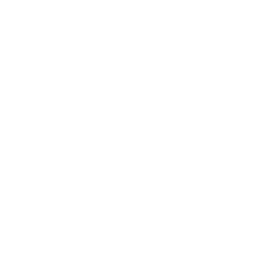
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Terästehtaan valssausprosessin seuranta</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Monimuuttujainen SPC kuumavalssaamon paksuuden ja pinnanlaadun ohjaukseen &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Kuumavalssaamo valssaa teräsaihiot ohueksi kelaksi. Kahdeksan korreloitunutta
prosessisignaalia (paksuudet, valssausvoima, telaväli, moottorin virta,
lähtölämpötila) liikkuvat yhdessä linjan ollessa kunnossa, joten niiden
seuranta yksi kaavio kerrallaan jättää huomaamatta yhteiset muutokset, jotka
ovat oleellisia. Tämä esimerkki rakentaa monimuuttujaisen perusmallin
**PROC MVPMODEL**illa ja virtauttaa sitten 100 tuotantokelaa
**PROC MVPMONITOR**in läpi, joka pisteyttää jokaisen kelan yhdellä
Hotellingin *T*&sup2;-tunnusluvulla ja vertaa sitä ohjausrajaan.

Kun hallinnassa olevan tilan raja on *T*&sup2; = **17,13** (&alpha; = 0,05),
**4 kelaa 100:sta** merkitään hallinnasta poikkeaviksi — kelat **91, 92, 94 ja
95**, täsmälleen se ikkuna, johon takatelan tärinäpurske injektoitiin.
Huippu-*T*&sup2; nousee arvoon **21,91** kelalla 95, noin **1,3**-kertaiseksi
rajaan nähden. Telojen vähittäinen kuluminen myöhemmillä keloilla nostaa
perustason *T*&sup2;-arvoa, mutta pysyy rajan alla tärinätapahtumaan asti,
joten kaavio erottaa selkeästi hitaan ajautumisen akuutista viasta, joka
vaatii välitöntä huomiota.

## Tietolähteet

- **mill_baseline** &mdash; 50 kelaa, jotka valssattiin kampanjan tunnetusti
  hyvän jakson aikana; käytetään monimuuttujaisen (PCA) referenssimallin
  sovittamiseen.
- **mill_stream** &mdash; 100 kelaa live-linjalta. Kelat 1&ndash;55 pysyvät
  hallinnassa; telojen kuluminen kehittyy vähitellen keloilla 56&ndash;100;
  takatelan tärinäpurske osuu keloihin 91&ndash;95.
- **Prosessimuuttujat** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Ympäristö toimii lisenssöimättömänä, joten aineistot on rajattu 100
> havaintoon. Skenaario on mitoitettu tämän rajan mukaiseksi: häiriö
> sijoitetaan myöhäiseen kohtaan 100 kelan virrassa sen sijaan, että se
> olisi kelalla 2 800/5 000.

---

### Vaihe 1 &mdash; Rakenna monimuuttujainen referenssimalli

`PROC MVPMODEL` suorittaa pääkomponenttianalyysin kuudelle prosessimuuttujalle
hallinnassa olevasta perusaineistosta ja kirjoittaa lataukset, ominaisarvot
sekä keskistämisen/skaalauksen tietoihin `mill_model`. Kolme komponenttia
säilytetään. Tämä malli määrittää, miltä "normaali" näyttää yhtenä
monimuuttujaisena alueena kuuden itsenäisen vaihteluvälin sijaan.

In [1]:
TIEDOT mill_baseline;
  CALL streaminit(66);
  TEE coil_id = 1 ASTI 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    TULOSTE;
  LOPPU;
  NIMIKE coil_id         = "Kelan tunnus"
        entry_thickness = "Tulopaksuus"
        exit_thickness  = "Lähtöpaksuus"
        rolling_force   = "Valssausvoima"
        roll_gap        = "Telaväli"
        motor_current   = "Moottorin virta"
        exit_temp       = "Lähtölämpötila";
SUORITA;

PROSEDUURI mvpmodel TIEDOT=mill_baseline outmodel=mill_model;
  MUUTTUJA entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
SUORITA;


                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         TulopaksuusLähtöpaksuusValssausvoima  TelaväliMoottorin virtaLähtölämpötila
  Tulopaksuus    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  Lähtöpaksuus   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  Valssausvoima   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  Telaväli   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  Moottorin virta    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  Lähtölämpötila    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Vaihe 2 &mdash; Virtauta tuotantokelat ja pisteytä ne

`PROC MVPMONITOR` projisoi jokaisen 100 tuotantokelasta tallennettuun
malliin ja laskee sen Hotellingin *T*&sup2;-arvon. Proseduuri johtaa
ohjausrajan mallin ulottuvuuksista ja oletusarvosta &alpha; = 0,05 ja
merkitsee sitten jokaisen kelan, jonka *T*&sup2; ylittää sen. Tulokset,
mukaan lukien sarakkeet `_TSQUARED`, `_LIMIT` ja `_SIGNAL`, kirjoitetaan
tietoihin `mill_scores` avaimena `coil_id`.

In [2]:
TIEDOT mill_stream;
  CALL streaminit(42);
  TEE coil_id = 1 ASTI 100;
    /* roll wear ramps 0 -> 1 over coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* backup-roll chatter burst on coils 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    POISTA wear chatter;
    TULOSTE;
  LOPPU;
  NIMIKE coil_id         = "Kelan tunnus"
        entry_thickness = "Tulopaksuus"
        exit_thickness  = "Lähtöpaksuus"
        rolling_force   = "Valssausvoima"
        roll_gap        = "Telaväli"
        motor_current   = "Moottorin virta"
        exit_temp       = "Lähtölämpötila";
SUORITA;

PROSEDUURI mvpmonitor TIEDOT=mill_stream MODEL=mill_model
                out=mill_scores;
  MUUTTUJA entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
SUORITA;


                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4
  Variables Monitored: Tulopaksuus, Lähtöpaksuus, Valssausvoima, Telaväli, Moottorin virta, Lähtölämpötila





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Proseduurin yhteenveto raportoi ohjausrajan ja merkkien lukumäärän.
Alla tulostettu viipale häiriön ympäriltä osoittaa, että perustason kelat
pysyvät selvästi rajan alla, kun taas tärinäikkuna nostaa neljä kelaa sen
yläpuolelle.

In [3]:
/* Flag out-of-control coils and capture the alarm T2 for plotting */
TIEDOT mill_scores;
  ASETA mill_scores;
  JOS _SIGNAL = 1 NIIN t2_alarm = _TSQUARED;
  MUUTEN t2_alarm = .;
  NIMIKE _TSQUARED = "T2-arvo"
        _LIMIT    = "T2:n yläraja"
        _SIGNAL   = "Poikkeamalippu"
        t2_alarm  = "T2-hälytysarvo";
SUORITA;

PROSEDUURI TULOSTA TIEDOT=mill_scores(firstobs=88 obs=96) noobs LABEL;
  MUUTTUJA coil_id _TSQUARED _LIMIT _SIGNAL;
  OTSIKKO 'T2-arvot tärinäikkunassa (kelat 88-96)';
SUORITA;

                                         T2-arvot tärinäikkunassa (kelat 88-96)                                         

coil_id    T2-arvo   T2:n yläraja  Poikkeamalippu
     88   9.983151      17.133408               0
     89   2.915646      17.133408               0
     90    7.80613      17.133408               0
     91  18.813814      17.133408               1
     92  18.249361      17.133408               1
     93  16.638221      17.133408               0
     94  17.981792      17.133408               1
     95  21.912329      17.133408               1
     96   5.118574      17.133408               0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Vaihe 3 &mdash; Monimuuttujainen ohjauskaavio

Kaavio asettaa kunkin kelan *T*&sup2;-arvon päällekkäin sen ohjausrajan
kanssa. Hallinnasta poikkeavat kelat korostetaan punaisella; katkoviivalla
merkitty pystysuora merkki osoittaa tärinäpurskeen alkamiskohdan. Hidas nousu
oikealle päin on telojen kulumisen nostamaa perustasoa; neljä punaista
pistettä ovat akuutti tärinävika.

                                         T2-arvot tärinäikkunassa (kelat 88-96)                                         




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


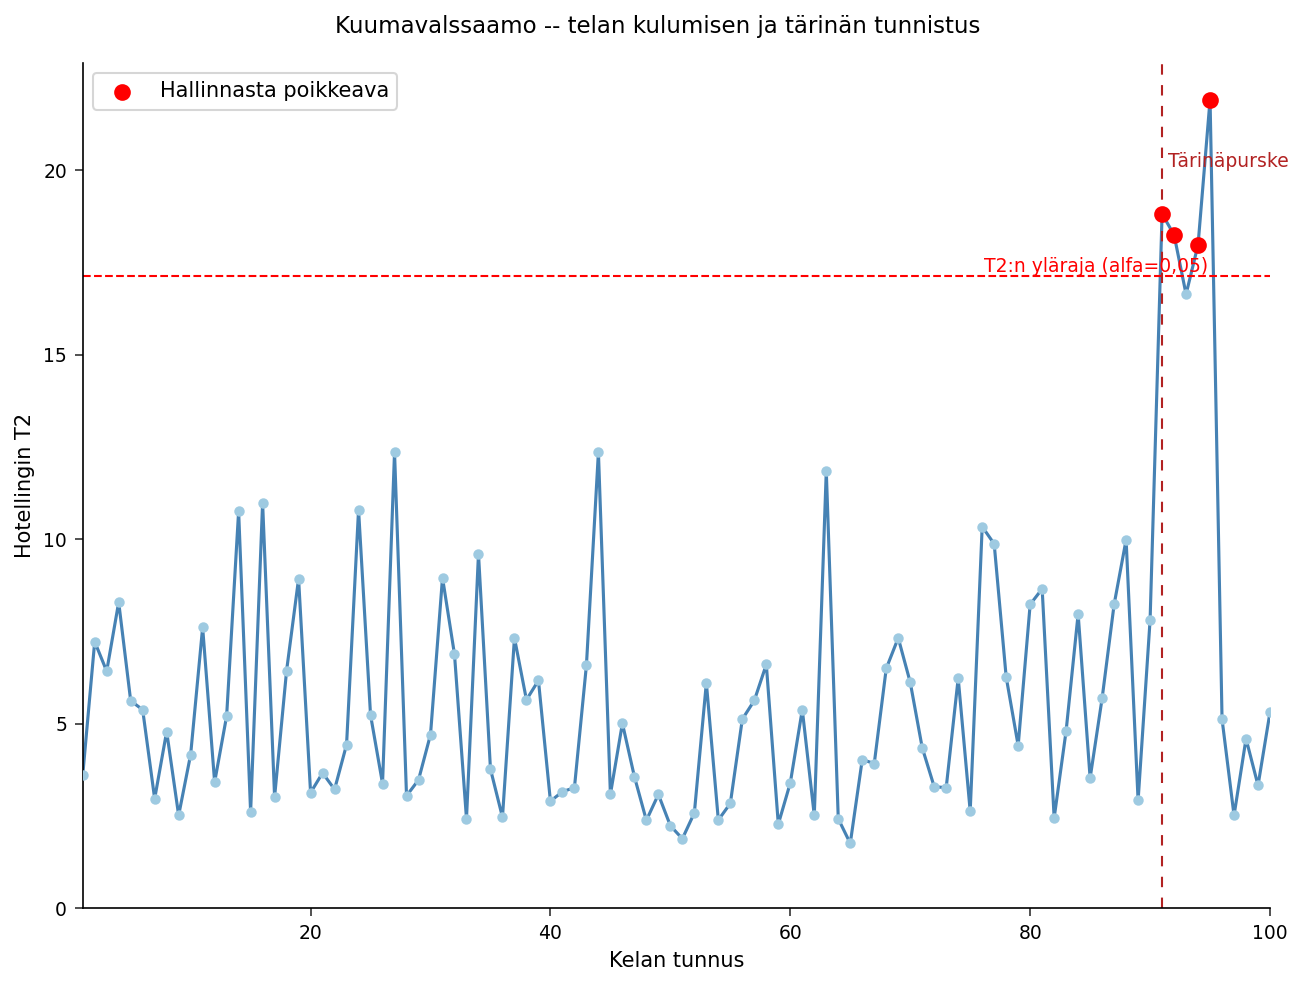

In [4]:
PROSEDUURI SGPLOT TIEDOT=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Hallinnasta poikkeava';
  REFLINE _LIMIT / AXIS=y
          LABEL='T2:n yläraja (alfa=0,05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x LABEL='Tärinäpurske'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS LABEL='Kelan tunnus' MIN=1 MAX=100;
  YAXIS LABEL="Hotellingin T2" MIN=0;
  OTSIKKO 'Kuumavalssaamo -- telan kulumisen ja tärinän tunnistus';
SUORITA;
OTSIKKO;

---

### Vaihe 4 &mdash; Määritä hallinnasta poikkeavien kelojen laajuus

Hallinnasta poikkeavat kelat reititetään erilliseen tietojoukkoon
laatuosastoa varten. `PROC MEANS` vertaa merkittyjen kelojen *T*&sup2;-tasoa
hallinnassa olevaan populaatioon, ja merkityt kelat viedään jatkokäsittelyyn
romutus-/korjausreititystä varten.

In [5]:
TIEDOT mill_ooc;
  ASETA mill_scores;
  JOS _SIGNAL = 1;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=mill_scores n mean MAX maxdec=2;
  LUOKKA _SIGNAL;
  MUUTTUJA _TSQUARED;
  OTSIKKO 'T2 ohjaustilan mukaan (0 = hallinnassa, 1 = hälytys)';
SUORITA;

PROSEDUURI TULOSTA TIEDOT=mill_ooc noobs LABEL;
  MUUTTUJA coil_id _TSQUARED _LIMIT;
  OTSIKKO 'Tarkastukseen merkityt hallinnasta poikkeavat kelat';
SUORITA;

PROSEDUURI VIE TIEDOT=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
SUORITA;

                                  T2 ohjaustilan mukaan (0 = hallinnassa, 1 = hälytys)                                  

                                                  The MEANS Procedure

                                         Analysis Variable : _TSQUARED T2-arvo

        Poikkeamalippu          N Obs           Mean        Maximum
        -----------------------------------------------------------
        0                          96           5.39          16.64
        1                           4          19.24          21.91
        -----------------------------------------------------------

                                  Tarkastukseen merkityt hallinnasta poikkeavat kelat                                   

coil_id    T2-arvo   T2:n yläraja
     91  18.813814      17.133408
     92  18.249361      17.133408
     94  17.981792      17.133408
     95  21.912329      17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Havainnot

- **Seurattuja keloja**: 100; **ohjausraja** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Hallinnasta poikkeavat kelat**: **4** &mdash; kelat **91, 92, 94, 95**,
  kaikki injektoidun tärinäikkunan (91&ndash;95) sisällä. Kela 93 huipentuu
  arvoon *T*&sup2; = 16,64, juuri rajan alle.
- **Suurin vakavuus**: *T*&sup2; = **21,91** kelalla 95 (noin 1,3-kertainen
  rajaan nähden); hallinnassa olevien kelojen keskiarvo on *T*&sup2;
  &asymp; **5,4**.
- **Kuluminen vs. vika**: telojen vähittäinen kuluminen nostaa myöhempien
  kelojen perustasoa, mutta ei koskaan ylitä rajaa yksinään, joten yksi
  monimuuttujainen kaavio erottaa hitaan ajautumisen (tarkkaile) akuutista
  tärinätapahtumasta (toimi).
- **Toimenpide**: neljä merkittyä kelaa viedään tiedostoon
  `steel_mill_ooc_coils.csv` tarkastusta ja romutus-/korjausreititystä
  varten; tärinän jälki osoittaa takatelan laakerin tarkastettavaksi ennen
  seuraavaa kampanjaa.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>